Loading Block C model objects...
  Block C objects loaded successfully.

D1: Computing odds ratios...
  Odds ratios table:
               Feature  Coef (β)       OR  OR_lower  OR_upper  p-value  Sig                  Interpretation
    Mean assess. score   -0.4275 0.652137  0.630779  0.674152   0.0000  *** decreases dropout odds by 34.8%
       Prior education   -0.0817 0.921548  0.888785  0.955520   0.0000  ***  decreases dropout odds by 7.8%
IMD band (deprivation)   -0.0322 0.968313  0.934447  1.003406   0.0766 n.s.           No significant effect
        Prev. attempts    0.0065 1.006521  0.973556  1.040603   0.7023 n.s.           No significant effect
              Age band    0.0095 1.009545  0.973945  1.046446   0.6032 n.s.           No significant effect
          Gender (M=1)    0.1216 1.129302  1.089915  1.169996   0.0000  *** increases dropout odds by 12.9%
     Disability status    0.1235 1.131450  1.095817  1.168125   0.0000  *** increases dropout odds by 13.1%
       Studie

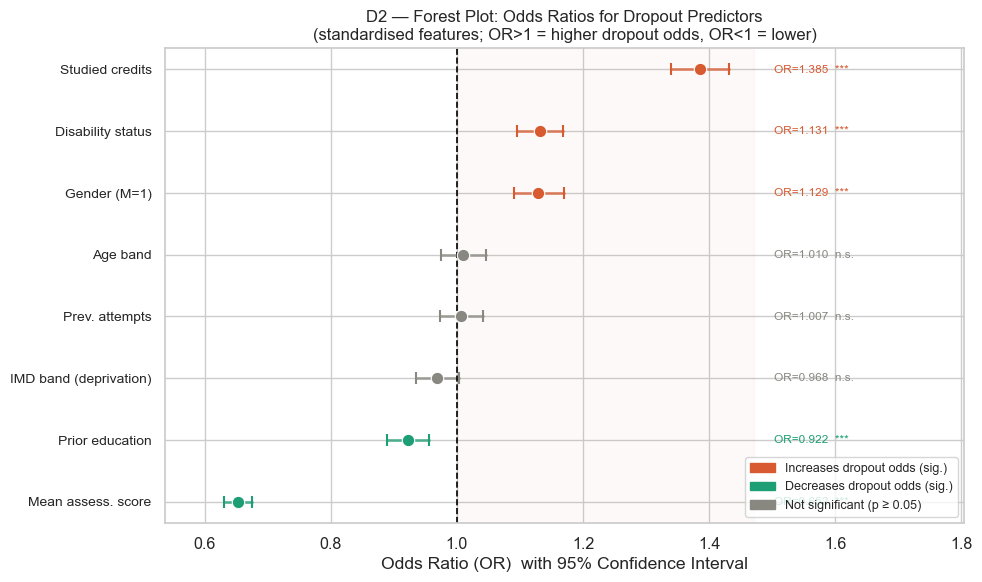

  Saved → ./outputs/phase3/block_d/D2_forest_plot.png

D3: Plain-English interpretations...

  Feature-by-feature interpretation:
  (Note: all effects are after controlling for all other features)

  🔴 Studied credits
     OR = 1.385  (***, p = 0.0000e+00)
     → A one standard deviation increase is associated with
       38.5% HIGHER odds of dropout.

  🔴 Disability status
     OR = 1.131  (***, p = 0.0000e+00)
     → A one standard deviation increase is associated with
       13.1% HIGHER odds of dropout.

  🔴 Gender (M=1)
     OR = 1.129  (***, p = 0.0000e+00)
     → A one standard deviation increase is associated with
       12.9% HIGHER odds of dropout.

  ⬜ Age band
     OR = 1.010  (p = 0.6032, not significant)
     → After controlling for other features, this feature does not
       significantly predict dropout on its own.

  ⬜ Prev. attempts
     OR = 1.007  (p = 0.7023, not significant)
     → After controlling for other features, this feature does not
       significantly p

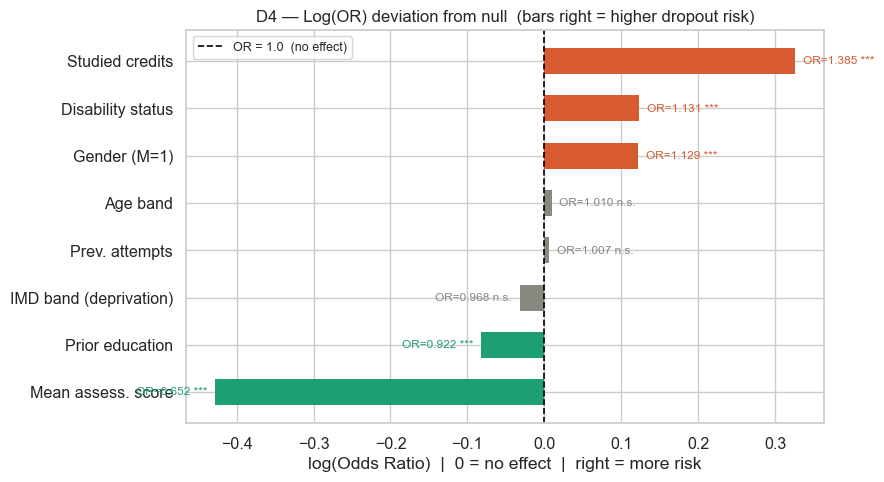

  Saved → ./outputs/phase3/block_d/D4_log_or_bar_chart.png

BLOCK D COMPLETE — Odds Ratios

  Features increasing dropout odds  : ['Gender (M=1)', 'Disability status', 'Studied credits']
  Features decreasing dropout odds  : ['Mean assess. score', 'Prior education']
  Features with no significant effect: ['IMD band (deprivation)', 'Prev. attempts', 'Age band']

  Strongest risk factor     : Studied credits
                              OR = 1.385
                              (+38.5% higher odds)

  Strongest protective factor: Mean assess. score
                              OR = 0.652
                              (-34.8% lower odds)

  Charts saved to: ./outputs/phase3/block_d/
    D2_forest_plot.png
    D4_log_or_bar_chart.png
    D1_odds_ratios.csv

─────────────────────────────────────────────────────────
Next → Run phase3_block_e_summary.py
─────────────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 3 — Block D: Odds Ratios and Effect Sizes
=============================================================
Goal: Convert logistic regression coefficients into interpretable
      odds ratios and visualise them as a forest plot.

What is an odds ratio (OR)?
  The logistic regression coefficient (β) is in log-odds units —
  hard to interpret directly.

  Exponentiating gives us the odds ratio:
    OR = exp(β)

  Interpretation:
    OR > 1.0 → feature INCREASES the odds of dropout
    OR < 1.0 → feature DECREASES the odds of dropout
    OR = 1.0 → feature has no effect on dropout odds

  Example:
    OR = 1.8 for "num_of_prev_attempts" means:
    "Each additional previous attempt is associated with
     1.8× higher odds of dropout."

    OR = 0.97 for "mean_score" means:
    "Each 1-unit increase in mean score is associated with
     3% lower odds of dropout."

What is a forest plot?
  A forest plot shows each feature's OR as a dot, with the
  95% confidence interval as a horizontal line (the "whisker").
  A vertical line at OR = 1.0 is the null (no effect) reference.
  If the CI crosses 1.0, the effect is not statistically significant.

Note: Because we standardised features in Block C, the coefficients
      reflect a ONE STANDARD DEVIATION change in each feature.
      This makes them directly comparable in magnitude.
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Config ────────────────────────────────────────────────────
BLOCK_C_PATH = './outputs/phase3/block_c/'
OUTPUT_PATH  = './outputs/phase3/block_d/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load Block C objects ───────────────────────────────────────
print("Loading Block C model objects...")
try:
    with open(os.path.join(BLOCK_C_PATH, 'block_c_objects.pkl'), 'rb') as f:
        c_objects = pickle.load(f)
    result          = c_objects['result']
    coef_df         = c_objects['coef_df']
    FEATURES        = c_objects['FEATURES']
    FEATURE_LABELS  = c_objects['FEATURE_LABELS']
    roc_auc         = c_objects['roc_auc']
    accuracy        = c_objects['accuracy']
    print("  Block C objects loaded successfully.\n")
except FileNotFoundError:
    print("  block_c_objects.pkl not found.")
    print("  Please run phase3_block_c_logistic_regression.py first.\n")
    raise


# =============================================================
# D1: Compute odds ratios and confidence intervals
# =============================================================
# OR   = exp(β)
# CI lower = exp(CI_lower from statsmodels)
# CI upper = exp(CI_upper from statsmodels)
#
# We work only on the feature rows (exclude the intercept).

print("D1: Computing odds ratios...")

# Filter to features only (no intercept)
features_only = coef_df[coef_df['Feature'] != 'Intercept'].copy()

# Exponentiate coefficients and CI bounds to get odds ratios
features_only['OR']       = np.exp(features_only['Coef (β)'])
features_only['OR_lower'] = np.exp(features_only['CI lower'])
features_only['OR_upper'] = np.exp(features_only['CI upper'])
features_only['Sig']      = features_only['p-value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
)

# Interpretation label
def interpret_or(row):
    if row['Sig'] == 'n.s.':
        return 'No significant effect'
    direction = 'increases' if row['OR'] > 1 else 'decreases'
    pct_change = abs(row['OR'] - 1) * 100
    return f"{direction} dropout odds by {pct_change:.1f}%"

features_only['Interpretation'] = features_only.apply(interpret_or, axis=1)

# Sort by OR descending for the forest plot
or_df = features_only.sort_values('OR', ascending=True).reset_index(drop=True)

print("  Odds ratios table:")
display_cols = ['Feature', 'Coef (β)', 'OR', 'OR_lower', 'OR_upper', 'p-value', 'Sig', 'Interpretation']
print(or_df[display_cols].to_string(index=False))
print()

# Save as CSV
or_path = os.path.join(OUTPUT_PATH, "D1_odds_ratios.csv")
or_df[display_cols].to_csv(or_path, index=False)
print(f"  Saved → {or_path}\n")


# =============================================================
# D2: Forest plot
# =============================================================
# The forest plot is the most portfolio-ready chart in Phase 3.
# Each row = one feature. Dot = OR. Horizontal line = 95% CI.
# Vertical line at OR = 1.0 = null reference (no effect).

print("D2: Drawing forest plot...")

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(or_df))   # one y-position per feature

# ── Colour by direction and significance ──────────────────────
def dot_color(row):
    if row['Sig'] == 'n.s.':  return COLORS['gray']
    return COLORS['coral'] if row['OR'] > 1 else COLORS['teal']

dot_colors = [dot_color(row) for _, row in or_df.iterrows()]

# ── Draw CI lines (whiskers) ──────────────────────────────────
for i, (_, row) in enumerate(or_df.iterrows()):
    color = dot_colors[i]
    # Horizontal CI line
    ax.plot(
        [row['OR_lower'], row['OR_upper']],
        [i, i],
        color=color,
        linewidth=2,
        alpha=0.7,
        solid_capstyle='round'
    )
    # CI cap marks at each end
    for x_end in [row['OR_lower'], row['OR_upper']]:
        ax.plot(x_end, i, '|', color=color, markersize=8, markeredgewidth=1.5)

# ── Draw OR dots ──────────────────────────────────────────────
for i, (_, row) in enumerate(or_df.iterrows()):
    ax.scatter(
        row['OR'], i,
        color=dot_colors[i],
        s=80,
        zorder=5,
        edgecolors='white',
        linewidths=0.8
    )

# ── Reference line at OR = 1 ─────────────────────────────────
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2,
           label='OR = 1.0  (no effect)')

# ── Y-axis: feature names ─────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(or_df['Feature'], fontsize=10)

# ── OR value and significance label to the right of each row ──
x_label_pos = or_df['OR_upper'].max() * 1.05
for i, (_, row) in enumerate(or_df.iterrows()):
    ax.text(
        x_label_pos, i,
        f"OR={row['OR']:.3f}  {row['Sig']}",
        va='center', fontsize=8.5,
        color=dot_colors[i] if row['Sig'] != 'n.s.' else COLORS['gray']
    )

# ── Shading: OR > 1 zone (increased risk) ────────────────────
ax.axvspan(1.0, ax.get_xlim()[1] if ax.get_xlim()[1] > 1 else 3,
           alpha=0.03, color=COLORS['coral'])

ax.set_title(
    "D2 — Forest Plot: Odds Ratios for Dropout Predictors\n"
    "(standardised features; OR>1 = higher dropout odds, OR<1 = lower)",
    fontsize=12
)
ax.set_xlabel("Odds Ratio (OR)  with 95% Confidence Interval")

# ── Legend ────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLORS['coral'], label='Increases dropout odds (sig.)'),
    mpatches.Patch(color=COLORS['teal'],  label='Decreases dropout odds (sig.)'),
    mpatches.Patch(color=COLORS['gray'],  label='Not significant (p ≥ 0.05)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')
ax.set_xlim(left=max(0, or_df['OR_lower'].min() * 0.85),
            right=x_label_pos + (x_label_pos - 1) * 0.6)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D2_forest_plot.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# D3: Plain-English interpretation table
# =============================================================
# Translate odds ratios into sentences for the portfolio report.

print("D3: Plain-English interpretations...")
print()
print("  Feature-by-feature interpretation:")
print("  (Note: all effects are after controlling for all other features)")
print()

for _, row in or_df.sort_values('OR', ascending=False).iterrows():
    or_val   = row['OR']
    sig      = row['Sig']
    feature  = row['Feature']
    p_val    = row['p-value']

    if sig == 'n.s.':
        sentence = (
            f"  ⬜ {feature}\n"
            f"     OR = {or_val:.3f}  (p = {p_val:.4f}, not significant)\n"
            f"     → After controlling for other features, this feature does not\n"
            f"       significantly predict dropout on its own.\n"
        )
    elif or_val > 1:
        pct     = (or_val - 1) * 100
        sentence = (
            f"  🔴 {feature}\n"
            f"     OR = {or_val:.3f}  ({sig}, p = {p_val:.4e})\n"
            f"     → A one standard deviation increase is associated with\n"
            f"       {pct:.1f}% HIGHER odds of dropout.\n"
        )
    else:
        pct     = (1 - or_val) * 100
        sentence = (
            f"  🟢 {feature}\n"
            f"     OR = {or_val:.3f}  ({sig}, p = {p_val:.4e})\n"
            f"     → A one standard deviation increase is associated with\n"
            f"       {pct:.1f}% LOWER odds of dropout.\n"
        )
    print(sentence)


# =============================================================
# D4: OR magnitude bar chart
# =============================================================
# A clean bar chart showing how far each OR deviates from 1.0.
# Bars extending right = OR > 1 (more risk).
# Bars extending left  = OR < 1 (less risk).
# This "diverging" style makes direction instantly readable.

print("D4: Plotting OR deviation bar chart...")

or_sorted = or_df.sort_values('OR').copy()
or_sorted['log_OR']  = np.log(or_sorted['OR'])    # log scale centres at 0
or_sorted['sig_flag'] = or_sorted['Sig'] != 'n.s.'

bar_colors = [
    (COLORS['coral'] if row['log_OR'] > 0 else COLORS['teal'])
    if row['sig_flag'] else COLORS['gray']
    for _, row in or_sorted.iterrows()
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    or_sorted['Feature'],
    or_sorted['log_OR'],
    color=bar_colors,
    edgecolor='none',
    height=0.55
)

# Reference line at log(OR) = 0 → OR = 1 (no effect)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--',
           label='OR = 1.0  (no effect)')

# Add OR value labels
for bar, (_, row) in zip(bars, or_sorted.iterrows()):
    x_offset = 0.01 if row['log_OR'] >= 0 else -0.01
    ha       = 'left' if row['log_OR'] >= 0 else 'right'
    ax.text(
        bar.get_width() + x_offset,
        bar.get_y() + bar.get_height() / 2,
        f"OR={row['OR']:.3f} {row['Sig']}",
        va='center', ha=ha, fontsize=8.5,
        color=bar_colors[list(or_sorted.index).index(row.name)]
    )

ax.set_title(
    "D4 — Log(OR) deviation from null  (bars right = higher dropout risk)",
    fontsize=12
)
ax.set_xlabel("log(Odds Ratio)  |  0 = no effect  |  right = more risk")
ax.legend(fontsize=9)
plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D4_log_or_bar_chart.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# BLOCK D SUMMARY
# =============================================================
sig_increase = or_df[(or_df['OR'] > 1) & (or_df['Sig'] != 'n.s.')]['Feature'].tolist()
sig_decrease = or_df[(or_df['OR'] < 1) & (or_df['Sig'] != 'n.s.')]['Feature'].tolist()
not_sig      = or_df[or_df['Sig'] == 'n.s.']['Feature'].tolist()

strongest_risk       = or_df[or_df['OR'] > 1].nlargest(1, 'OR').iloc[0]
strongest_protective = or_df[or_df['OR'] < 1].nsmallest(1, 'OR').iloc[0]

print("=" * 60)
print("BLOCK D COMPLETE — Odds Ratios")
print("=" * 60)
print(f"""
  Features increasing dropout odds  : {sig_increase}
  Features decreasing dropout odds  : {sig_decrease}
  Features with no significant effect: {not_sig}

  Strongest risk factor     : {strongest_risk['Feature']}
                              OR = {strongest_risk['OR']:.3f}
                              (+{(strongest_risk['OR']-1)*100:.1f}% higher odds)

  Strongest protective factor: {strongest_protective['Feature']}
                              OR = {strongest_protective['OR']:.3f}
                              (-{(1-strongest_protective['OR'])*100:.1f}% lower odds)

  Charts saved to: {OUTPUT_PATH}
    D2_forest_plot.png
    D4_log_or_bar_chart.png
    D1_odds_ratios.csv

─────────────────────────────────────────────────────────
Next → Run phase3_block_e_summary.py
─────────────────────────────────────────────────────────
""")